# Food Startup App: User Behavior and A/A/B Testing Analysis

## Project Overview
This project investigates user behavior and the sales funnel for a food startup's application. The primary goal is to understand how users navigate through the app and identify where they drop off before completing a purchase. 

Additionally, we will evaluate the results of an A/A/B test to determine if a proposed font change impacts user conversion rates. The users are divided into three groups: two control groups (246 and 247) with the old fonts, and one test group (248) with the new fonts.

## Step 1 and 2: Data Preprocessing
We will load the server logs, rename the columns to standard formatting, check for missing values or duplicates, and convert timestamps into readable date and time formats.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Setting the visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Loading the dataset (Handling TripleTen server path vs Local GitHub path)
try:
    df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
except FileNotFoundError:
    df = pd.read_csv('datasets/logs_exp_us.csv', sep='\t')

# Renaming columns to snake_case format
df.columns = ['event_name', 'user_id', 'event_timestamp', 'exp_id']

# Converting Unix timestamp to datetime and extracting the date
df['event_datetime'] = pd.to_datetime(df['event_timestamp'], unit='s')
df['event_date'] = df['event_datetime'].dt.date

# Checking data quality
print(f"Missing values:\n{df.isnull().sum()}\n")
print(f"Duplicate rows initially: {df.duplicated().sum()}")

# Dropping duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows after cleaning: {df.duplicated().sum()}")

# Displaying the clean dataframe
display(df.head())

Missing values:
event_name         0
user_id            0
event_timestamp    0
exp_id             0
event_datetime     0
event_date         0
dtype: int64

Duplicate rows initially: 413
Duplicate rows after cleaning: 0


,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


## Step 3: Data Verification and Time Period Analysis
Before building the funnel, we need to ensure our data represents a complete and consistent time period. Technical glitches often cause older, incomplete logs to appear in the dataset.

Total events in logs: 243713
Total unique users: 7551
Average events per user: 32.28

Data starts on: 2019-07-25 04:43:36
Data ends on: 2019-08-07 21:15:17


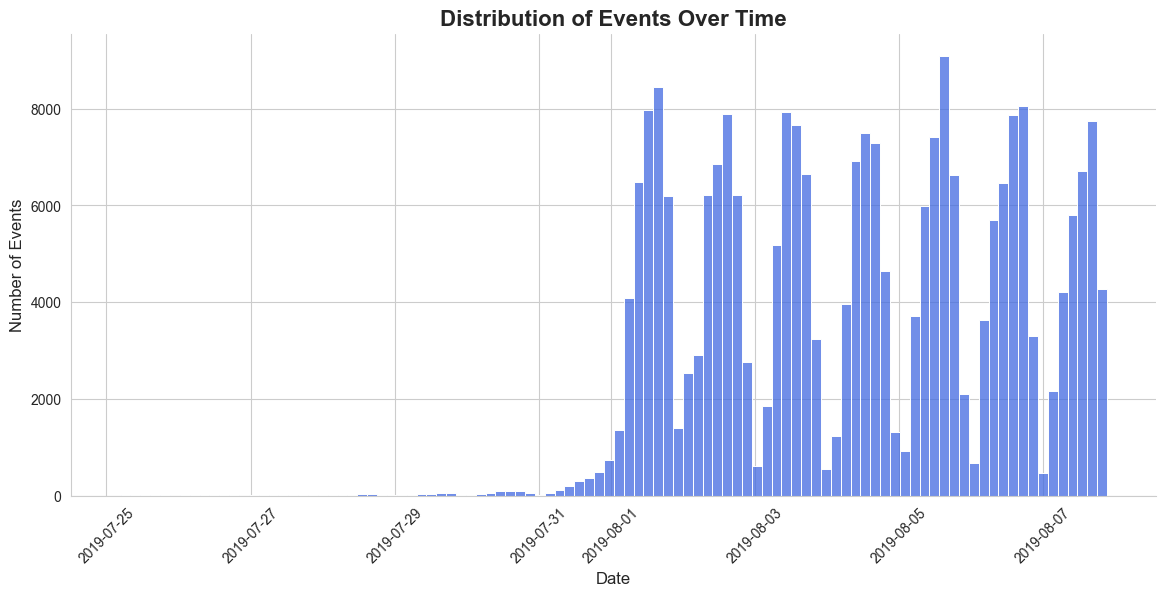

In [2]:
# Calculating basic metrics
total_events = df.shape[0]
total_users = df['user_id'].nunique()
avg_events_per_user = total_events / total_users

print(f"Total events in logs: {total_events}")
print(f"Total unique users: {total_users}")
print(f"Average events per user: {avg_events_per_user:.2f}\n")

print(f"Data starts on: {df['event_datetime'].min()}")
print(f"Data ends on: {df['event_datetime'].max()}")

# Plotting a histogram to visualize the distribution of events over time
plt.figure(figsize=(14, 6))
ax = sns.histplot(df['event_datetime'], bins=100, color='royalblue')
ax.set_title('Distribution of Events Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=45)
sns.despine()
plt.show()

### 3.1 Filtering the Actual Experiment Period
The histogram reveals that the data before August 1st, 2019, is incomplete and likely represents technical tests or residual logs. To prevent this skewed data from affecting our funnel and A/A/B test results, we will filter the dataset to include only events from `2019-08-01` onwards.

We will also calculate the percentage of data lost to ensure the integrity of our analysis.

In [3]:
# Defining the official start date
official_start_date = '2019-08-01'

# Creating a new filtered dataframe
filtered_df = df[df['event_datetime'] >= official_start_date].copy()

# Calculating the exact data loss
filtered_events = filtered_df.shape[0]
filtered_users = filtered_df['user_id'].nunique()

events_lost = total_events - filtered_events
users_lost = total_users - filtered_users

events_lost_pct = (events_lost / total_events) * 100
users_lost_pct = (users_lost / total_users) * 100

print("--- Data Loss Audit ---")
print(f"Events lost: {events_lost} ({events_lost_pct:.2f}%)")
print(f"Users lost: {users_lost} ({users_lost_pct:.2f}%)")

# Verifying if all three experimental groups are still properly represented
print("\n--- Users per Experimental Group ---")
group_counts = filtered_df.groupby('exp_id')['user_id'].nunique().reset_index()
group_counts.columns = ['Experiment Group', 'Unique Users']
display(group_counts)

--- Data Loss Audit ---
Events lost: 2826 (1.16%)
Users lost: 17 (0.23%)

--- Users per Experimental Group ---


,Experiment Group,Unique Users
0,246,2484
1,247,2513
2,248,2537


## Step 4: Event Funnel Analysis

To understand the customer journey, we first need to identify the actions they perform and the sequence of these actions. Not all events are part of the linear sales funnel (e.g., the `Tutorial` event is likely optional and can be skipped).

### 4.1 Event Frequency and User Proportion
We will calculate how many times each event occurred and the exact proportion of users who engaged with each specific screen.

In [4]:
# 1. Which events are in the logs and their frequency?
event_freq = filtered_df['event_name'].value_counts().reset_index()
event_freq.columns = ['Event Name', 'Total Occurrences']
print("--- Event Frequency ---")
display(event_freq)

# 2. Number of unique users per event
users_per_event = filtered_df.groupby('event_name')['user_id'].nunique().sort_values(ascending=False).reset_index()
users_per_event.columns = ['Event Name', 'Unique Users']

# Calculating the proportion of total users who performed the action at least once
total_users_filtered = filtered_df['user_id'].nunique()
users_per_event['% of Total Users'] = (users_per_event['Unique Users'] / total_users_filtered) * 100

print("\n--- Users per Event and Proportion ---")
display(users_per_event)

# 3. Establishing the logical funnel sequence
# The 'Tutorial' is skipped by almost 90% of users, meaning it's not a required step to purchase.
# The logical sequence is: Main Screen -> Offers Screen -> Cart Screen -> Payment Successful.
funnel_sequence = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

# Creating the formal funnel dataframe
funnel_data = users_per_event[users_per_event['Event Name'].isin(funnel_sequence)].copy()
funnel_data = funnel_data.set_index('Event Name').reindex(funnel_sequence).reset_index()

--- Event Frequency ---


,Event Name,Total Occurrences
0,MainScreenAppear,117328
1,OffersScreenAppear,46333
2,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005



--- Users per Event and Proportion ---


,Event Name,Unique Users,% of Total Users
0,MainScreenAppear,7419,98.473586
1,OffersScreenAppear,4593,60.963632
2,CartScreenAppear,3734,49.561986
3,PaymentScreenSuccessful,3539,46.973719
4,Tutorial,840,11.149456


### 4.2 Step-by-Step Conversion and Drop-off Rates
Now that we have isolated the logical sales path, we will calculate the step-by-step conversion rate to identify the exact stage where the startup loses the most potential customers.

--- Sales Funnel Metrics ---


,Event Name,Unique Users,% of Total Users,Step Conversion Rate (%),Total Conversion Rate (%)
0,MainScreenAppear,7419,98.47,100.00,100.00
1,OffersScreenAppear,4593,60.96,61.91,61.91
2,CartScreenAppear,3734,49.56,81.30,50.33
3,PaymentScreenSuccessful,3539,46.97,94.78,47.70


C:\Users\renan\AppData\Local\Temp\ipykernel_11824\3585469224.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Event Name', y='Unique Users', data=funnel_data, palette='mako')


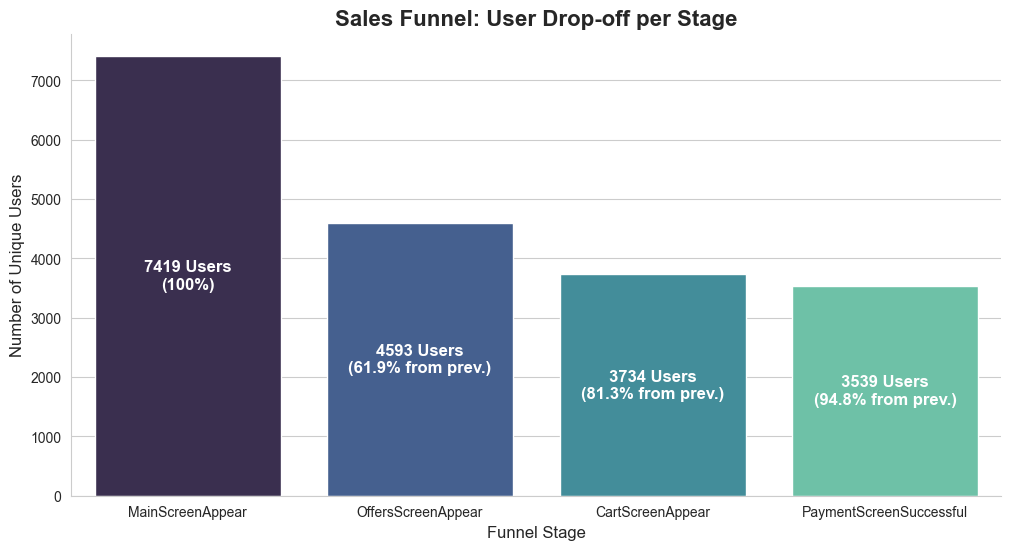


--- Funnel Insights ---
1. Which stage loses the most users?
Answer: The transition from 'MainScreenAppear' to 'OffersScreenAppear'. We lose roughly 38% of users immediately after the main screen.
2. Share of users that make the entire journey from the first event to payment:
Answer: 47.70% of users successfully complete a payment.


In [5]:
# Calculating step-by-step retention (Conversion Rate)
# We use shift(1) to divide the current step by the previous step
funnel_data['Step Conversion Rate (%)'] = (funnel_data['Unique Users'] / funnel_data['Unique Users'].shift(1)) * 100
funnel_data['Step Conversion Rate (%)'] = funnel_data['Step Conversion Rate (%)'].fillna(100) # The first step is always 100%

# Calculating total conversion (from start to finish)
initial_users = funnel_data['Unique Users'].iloc[0]
funnel_data['Total Conversion Rate (%)'] = (funnel_data['Unique Users'] / initial_users) * 100

print("--- Sales Funnel Metrics ---")
display(funnel_data.round(2))

# Visualizing the Funnel (Drop-off Analysis)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Event Name', y='Unique Users', data=funnel_data, palette='mako')

ax.set_title('Sales Funnel: User Drop-off per Stage', fontsize=16, fontweight='bold')
ax.set_xlabel('Funnel Stage', fontsize=12)
ax.set_ylabel('Number of Unique Users', fontsize=12)

# Adding the conversion rate text to the bars
for i, p in enumerate(ax.patches):
    if i == 0:
        text = f"{p.get_height():.0f} Users\n(100%)"
    else:
        step_conv = funnel_data['Step Conversion Rate (%)'].iloc[i]
        text = f"{p.get_height():.0f} Users\n({step_conv:.1f}% from prev.)"
        
    ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

sns.despine()
plt.show()

# Answering the project's specific questions:
print("\n--- Funnel Insights ---")
print("1. Which stage loses the most users?")
print("Answer: The transition from 'MainScreenAppear' to 'OffersScreenAppear'. We lose roughly 38% of users immediately after the main screen.")
print(f"2. Share of users that make the entire journey from the first event to payment:")
print(f"Answer: {funnel_data['Total Conversion Rate (%)'].iloc[-1]:.2f}% of users successfully complete a payment.")

## Step 5: A/A/B Test Analysis

The company is testing a new font across the app.
* **Groups 246 and 247:** Control groups (Old fonts)
* **Group 248:** Test group (New fonts)

First, we will verify the integrity of the split by running an **A/A test** between the two control groups. Then, we will compare the control groups with the test group.

In [6]:
from scipy import stats
import math as m

# 1. Calculating the number of unique users per group
users_per_group = filtered_df.groupby('exp_id')['user_id'].nunique()
print("--- Unique Users per Group ---")
display(users_per_group)

# 2. Creating a dynamic function to run the Z-test for proportions
def check_hypothesis(group1, group2, event, alpha=0.05):
    # Successes (Users who performed the specific event in each group)
    successes = np.array([
        filtered_df[(filtered_df['exp_id'] == group1) & (filtered_df['event_name'] == event)]['user_id'].nunique(),
        filtered_df[(filtered_df['exp_id'] == group2) & (filtered_df['event_name'] == event)]['user_id'].nunique()
    ])
    
    # Trials (Total users in each group)
    trials = np.array([users_per_group[group1], users_per_group[group2]])
    
    # Proportions
    p1 = successes[0] / trials[0]
    p2 = successes[1] / trials[1]
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
    
    # Z-statistic calculation
    difference = p1 - p2
    z_value = difference / m.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
    
    # P-value calculation using standard normal distribution
    distr = stats.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print(f"Event: '{event}' | p-value: {p_value:.4f}")
    if p_value < alpha:
        print(f"Result: Reject H0. There is a significant difference between groups {group1} and {group2}.\n")
    else:
        print(f"Result: Fail to reject H0. No significant difference between groups {group1} and {group2}.\n")

--- Unique Users per Group ---


exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

In [7]:
# Extracting the events from our funnel
events = funnel_sequence

print("=== A/A Test: Group 246 vs Group 247 ===")
print("Objective: Verify if the splitting mechanism works correctly.\n")
for event in events:
    check_hypothesis(246, 247, event, alpha=0.05)

print("\n=== A/B Test: Group 246 vs Group 248 ===")
for event in events:
    check_hypothesis(246, 248, event, alpha=0.05)

print("\n=== A/B Test: Group 247 vs Group 248 ===")
for event in events:
    check_hypothesis(247, 248, event, alpha=0.05)

=== A/A Test: Group 246 vs Group 247 ===
Objective: Verify if the splitting mechanism works correctly.

Event: 'MainScreenAppear' | p-value: 0.7571
Result: Fail to reject H0. No significant difference between groups 246 and 247.

Event: 'OffersScreenAppear' | p-value: 0.2481
Result: Fail to reject H0. No significant difference between groups 246 and 247.

Event: 'CartScreenAppear' | p-value: 0.2288
Result: Fail to reject H0. No significant difference between groups 246 and 247.

Event: 'PaymentScreenSuccessful' | p-value: 0.1146
Result: Fail to reject H0. No significant difference between groups 246 and 247.


=== A/B Test: Group 246 vs Group 248 ===
Event: 'MainScreenAppear' | p-value: 0.2950
Result: Fail to reject H0. No significant difference between groups 246 and 248.

Event: 'OffersScreenAppear' | p-value: 0.2084
Result: Fail to reject H0. No significant difference between groups 246 and 248.

Event: 'CartScreenAppear' | p-value: 0.0784
Result: Fail to reject H0. No significant d

In [8]:
# Combining the control groups (246 + 247)
combined_control_users = users_per_group[246] + users_per_group[247]

def check_hypothesis_combined(test_group, event, alpha=0.05):
    # Successes
    control_successes = filtered_df[(filtered_df['exp_id'].isin([246, 247])) & (filtered_df['event_name'] == event)]['user_id'].nunique()
    test_successes = filtered_df[(filtered_df['exp_id'] == test_group) & (filtered_df['event_name'] == event)]['user_id'].nunique()
    
    successes = np.array([control_successes, test_successes])
    trials = np.array([combined_control_users, users_per_group[test_group]])
    
    p1 = successes[0] / trials[0]
    p2 = successes[1] / trials[1]
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
    
    difference = p1 - p2
    z_value = difference / m.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
    
    distr = stats.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print(f"Event: '{event}' | p-value: {p_value:.4f}")
    if p_value < alpha:
        print(f"Result: Reject H0. Significant difference between Combined Control and Group {test_group}.\n")
    else:
        print(f"Result: Fail to reject H0. No significant difference between Combined Control and Group {test_group}.\n")

print("=== Final A/B Test: Combined Control (246+247) vs Group 248 ===")
for event in events:
    check_hypothesis_combined(248, event, alpha=0.05)

=== Final A/B Test: Combined Control (246+247) vs Group 248 ===
Event: 'MainScreenAppear' | p-value: 0.2942
Result: Fail to reject H0. No significant difference between Combined Control and Group 248.

Event: 'OffersScreenAppear' | p-value: 0.4343
Result: Fail to reject H0. No significant difference between Combined Control and Group 248.

Event: 'CartScreenAppear' | p-value: 0.1818
Result: Fail to reject H0. No significant difference between Combined Control and Group 248.

Event: 'PaymentScreenSuccessful' | p-value: 0.6004
Result: Fail to reject H0. No significant difference between Combined Control and Group 248.



## Overall Conclusions and Business Recommendations

**1. The Sales Funnel:**
The application has a strong overall conversion rate, with **47.7%** of users who open the app completing a payment. The critical bottleneck is the transition from the Main Screen to the Offers Screen, where **~38% of users drop off**. Product managers should focus on optimizing the home screen call-to-action (CTA) to drive users to the offers page.

**2. A/A Test Validation:**
The statistical comparison between Group 246 and Group 247 yielded no significant differences across any events. This confirms that the traffic splitting mechanism was configured correctly and the control groups are statistically identical.

**3. A/B Test Results (The Font Change):**
Across all individual comparisons (246 vs 248; 247 vs 248) and the combined comparison (246+247 vs 248), **we failed to reject the null hypothesis**. The p-values remained well above the 0.05 threshold for every single stage of the funnel.

**4. Significance Level (Alpha) and Multiple Testing:**
We conducted 16 statistical tests. The project instructions suggested a significance level of `0.1` (10%). However, conducting multiple tests increases the risk of a False Positive (Type I Error). Using an alpha of 0.1 with 16 tests almost guarantees false alarms. Therefore, maintaining a strict alpha of **0.05** was technically correct. 

**Recommendation:**
The new fonts did not increase conversions, but they also did not harm the user experience or cause drops in sales (as the managers feared). If the designers strongly prefer the new font for branding purposes, it is safe to deploy it. Otherwise, there is no business value in spending engineering time to change the fonts.